### CARGAR DATOS

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df_trips = pd.read_csv('/datasets/project_sql_result_01.csv')
df_location = pd.read_csv('/datasets/project_sql_result_04.csv')
df_to_airport = pd.read_csv('/datasets/project_sql_result_07.csv') 

### REVISION Y LIMPIEZA DE DATOS

In [3]:
print(df_trips.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None


In [4]:
print(df_trips.head())

                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                Medallion Leasing         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299


In [5]:
print(df_trips.describe())

       trips_amount
count     64.000000
mean    2145.484375
std     3812.310186
min        2.000000
25%       20.750000
50%      178.500000
75%     2106.500000
max    19558.000000


In [6]:
print(df_location.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
None


In [7]:
print(df_location.head())

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000


In [8]:
print(df_location.describe())

       average_trips
count      94.000000
mean      599.953728
std      1714.591098
min         1.800000
25%        14.266667
50%        52.016667
75%       298.858333
max     10727.466667


In [9]:
print(df_to_airport.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB
None


In [10]:
print(df_to_airport.head())

              start_ts weather_conditions  duration_seconds
0  2017-11-25 16:00:00               Good            2410.0
1  2017-11-25 14:00:00               Good            1920.0
2  2017-11-25 12:00:00               Good            1543.0
3  2017-11-04 10:00:00               Good            2512.0
4  2017-11-11 07:00:00               Good            1440.0


In [11]:
print(df_to_airport.describe())

       duration_seconds
count       1068.000000
mean        2071.731273
std          769.461125
min            0.000000
25%         1438.250000
50%         1980.000000
75%         2580.000000
max         7440.000000


In [12]:
#Cambiar tipo de dato de df_to_airport['start_ts'] a datetime
df_to_airport['start_ts'] = pd.to_datetime(df_to_airport['start_ts'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

#check the result
df_to_airport.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   start_ts            1068 non-null   datetime64[ns]
 1   weather_conditions  1068 non-null   object        
 2   duration_seconds    1068 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 25.2+ KB


Comentario sobre tipo de datos:<br>df_trips:<br>
company_name: tipo object (correcto para cadenas de texto).<br>
trips_amount: tipo int64 (correcto para contar viajes).

df_locations:<br>dropoff_location_name: tipo object (correcto para cadenas de texto).<br>
average_trips: tipo float64 (correcto para valores promedios, que pueden ser decimales).

df_to_airport:<br>start_ts: tipo object (Debería ser un tipo de dato relacionado con fechas/horas, como datetime).Fue corregido a tipo datetime.<br>weather_conditions: tipo object (Está correcto porque se usa para almacenar cadenas de texto (strings)).<br>duration_seconds: tipo float64 (Es adecuado para representar duraciones en segundos, ya que se puede tener valores decimales en la duración).

#### Eliminar duplicados explicitos

In [13]:
# Contar nombres de empresas duplicados
duplicados_company_name = df_trips['company_name'].duplicated().sum()
print("Número de duplicados de company_name en trips:", duplicados_company_name)

Número de duplicados de company_name en trips: 0


In [14]:
# Contar nombres de la ubicación donde finalizó el viaje duplicados en locations
duplicados_dropoff_location_name = df_location['dropoff_location_name'].duplicated().sum()
print("Número de duplicados de dropoff_location_name en locations:", duplicados_dropoff_location_name)

Número de duplicados de dropoff_location_name en locations: 0


In [15]:
# Contar duplicados en df_to_airport
duplicados_to_airport = df_to_airport.duplicated().sum()
print("Número de filas duplicadas en df_to_airport:", duplicados_to_airport)

Número de filas duplicadas en df_to_airport: 197


Comentario:<br>No se encontró valores duplicados en df_trips y df_location, pero si se encontraron filas duplicadas en df_to_airport.Sin embargo, no se cuenta con una columna como trip_id que identifique si son unicos o duplicados. Por lo tanto, decidí mantener esos datos.

#### Eliminar Duplicados implicitos

In [16]:
# Convertir la columna 'company_name' a una lista y ordenarla alfabéticamente
company_names = sorted(df_trips['company_name'].tolist())

# Mostrar la lista ordenada
print(company_names)

['0118 - 42111 Godfrey S. Awir', '1085 - 72312 N and W Cab Co', '1469 - 64126 Omar Jada', '2092 - 61288 Sbeih Company', '2192 - 73487 Zeymane Corp', '2241 - 44667 - Felman Corp', '24 Seven Taxi', '2733 - 74600 Benny Jona', '2809 - 95474 C & D Cab Co Inc.', '2823 - 73307 Lee Express Inc', '3011 - 66308 JBL Cab Inc.', '303 Taxi', '3556 - 36214 RC Andrews Cab', '3591 - 63480 Chuks Cab', '3620 - 52292 David K. Cab Corp.', '3623 - 72222 Arrington Enterprises', '3721 - Santamaria Express', '4053 - 40193 Adwar H. Nikola', '4615 - 83503 Tyrone Henderson', '4623 - 27290 Jay Kim', '5 Star Taxi', '5006 - 39261 Salifu Bawa', '5062 - 34841 Sam Mestas', '5074 - 54002 Ahzmi Inc', '5874 - 73628 Sergey Cab Corp.', '5997 - 65283 AW Services Inc.', '6057 - 24657 Richard Addo', '6574 - Babylon Express Inc.', '6742 - 83735 Tasha Ride Inc', '6743 - 78771 Luhak Corp', 'American United', 'American United Taxi Affiliation', 'Blue Diamond', 'Blue Ribbon Taxi Association Inc.', 'Checker Taxi', 'Checker Taxi Affi

In [21]:
# Normalización: eliminar espacios al inicio y al final, y convertir a minúsculas
def normalize(name):
    return name.strip().lower()  # Eliminar espacios y convertir a minúsculas

# Aplicar normalización a todos los nombres
normalized_company_names = [normalize(name) for name in company_names]

# Mostrar los nombres normalizados
print(normalized_company_names)

['0118 - 42111 godfrey s. awir', '1085 - 72312 n and w cab co', '1469 - 64126 omar jada', '2092 - 61288 sbeih company', '2192 - 73487 zeymane corp', '2241 - 44667 - felman corp', '24 seven taxi', '2733 - 74600 benny jona', '2809 - 95474 c & d cab co inc.', '2823 - 73307 lee express inc', '3011 - 66308 jbl cab inc.', '303 taxi', '3556 - 36214 rc andrews cab', '3591 - 63480 chuks cab', '3620 - 52292 david k. cab corp.', '3623 - 72222 arrington enterprises', '3721 - santamaria express', '4053 - 40193 adwar h. nikola', '4615 - 83503 tyrone henderson', '4623 - 27290 jay kim', '5 star taxi', '5006 - 39261 salifu bawa', '5062 - 34841 sam mestas', '5074 - 54002 ahzmi inc', '5874 - 73628 sergey cab corp.', '5997 - 65283 aw services inc.', '6057 - 24657 richard addo', '6574 - babylon express inc.', '6742 - 83735 tasha ride inc', '6743 - 78771 luhak corp', 'american united', 'american united taxi affiliation', 'blue diamond', 'blue ribbon taxi association inc.', 'checker taxi', 'checker taxi affi

In [22]:
count_normalized_company_names = len(normalized_company_names)
print(f"Cantidad de nombres normalizados: {count_normalized_company_names}")

Cantidad de nombres normalizados: 64


In [23]:
# Convertir la columna 'dropoff_location_name' a una lista y ordenarla alfabéticamente
location_names = sorted(df_location['dropoff_location_name'].tolist())

# Mostrar la lista ordenada
print(location_names)

['Albany Park', 'Andersonville', 'Archer Heights', 'Armour Square', 'Ashburn', 'Auburn Gresham', 'Austin', 'Avalon Park', 'Avondale', 'Belmont Cragin', 'Beverly', 'Boystown', 'Bridgeport', 'Brighton Park', 'Bucktown', 'Burnside', 'Calumet Heights', 'Chatham', 'Chicago Lawn', 'Chinatown', 'Clearing', 'Douglas', 'Dunning', 'East Side', 'East Village', 'Edgewater', 'Edison Park', 'Englewood', 'Fuller Park', 'Gage Park', 'Garfield Park', 'Garfield Ridge', 'Gold Coast', 'Grand Boulevard', 'Grand Crossing', 'Grant Park', 'Hegewisch', 'Hermosa', 'Humboldt Park', 'Hyde Park', 'Irving Park', 'Jackson Park', 'Jefferson Park', 'Kenwood', 'Lake View', 'Lincoln Park', 'Lincoln Square', 'Little Italy, UIC', 'Little Village', 'Logan Square', 'Loop', 'Lower West Side', 'Mckinley Park', 'Montclare', 'Morgan Park', 'Mount Greenwood', 'Museum Campus', 'Near South Side', 'New City', 'North Center', 'North Lawndale', 'North Park', 'Norwood Park', "O'Hare", 'Oakland', 'Old Town', 'Portage Park', 'Pullman', 

In [24]:
# Normalización: eliminar espacios al inicio y al final, y convertir a minúsculas
def normalize(name):
    return name.strip().lower()  # Eliminar espacios y convertir a minúsculas

# Aplicar normalización a todos los nombres
normalized_location = [normalize(name) for name in location_names]

# Mostrar los nombres normalizados
print(normalized_location)

['albany park', 'andersonville', 'archer heights', 'armour square', 'ashburn', 'auburn gresham', 'austin', 'avalon park', 'avondale', 'belmont cragin', 'beverly', 'boystown', 'bridgeport', 'brighton park', 'bucktown', 'burnside', 'calumet heights', 'chatham', 'chicago lawn', 'chinatown', 'clearing', 'douglas', 'dunning', 'east side', 'east village', 'edgewater', 'edison park', 'englewood', 'fuller park', 'gage park', 'garfield park', 'garfield ridge', 'gold coast', 'grand boulevard', 'grand crossing', 'grant park', 'hegewisch', 'hermosa', 'humboldt park', 'hyde park', 'irving park', 'jackson park', 'jefferson park', 'kenwood', 'lake view', 'lincoln park', 'lincoln square', 'little italy, uic', 'little village', 'logan square', 'loop', 'lower west side', 'mckinley park', 'montclare', 'morgan park', 'mount greenwood', 'museum campus', 'near south side', 'new city', 'north center', 'north lawndale', 'north park', 'norwood park', "o'hare", 'oakland', 'old town', 'portage park', 'pullman', 

In [25]:
count_normalized_location_names = len(normalized_location)
print(f"Cantidad de nombres normalizados: {count_normalized_location_names}")

Cantidad de nombres normalizados: 94


Comentario:<br>Se normalizó el campo de company_name y dropoff_location_name, se eliminó espacios y convitió todo en minúscula, de manera que sigan un formato estándar y uniforme, lo cual facilitó el análisis. No se encontraron duplicados implícitos.

#### Valores nulos

In [26]:
# Revisar si hay valores nulos en los dataframes
print(df_trips.isnull().sum())
print(df_location.isnull().sum())
print(df_to_airport.isnull().sum())

company_name    0
trips_amount    0
dtype: int64
dropoff_location_name    0
average_trips            0
dtype: int64
start_ts              0
weather_conditions    0
duration_seconds      0
dtype: int64


#### Valores = 0

In [27]:
# Verificar si hay valores 0 en la columna 'duration_seconds'
zero_duration_count = (df_to_airport['duration_seconds'] == 0).sum()

# Mostrar el resultado
print(f"\nHay {zero_duration_count} registros con duration_seconds igual a 0.\n")
print(df_to_airport[df_to_airport['duration_seconds'] == 0])


Hay 6 registros con duration_seconds igual a 0.

                start_ts weather_conditions  duration_seconds
163  2017-11-11 09:00:00               Good               0.0
168  2017-11-11 07:00:00               Good               0.0
204  2017-11-18 19:00:00               Good               0.0
552  2017-11-04 01:00:00               Good               0.0
801  2017-11-04 09:00:00               Good               0.0
1063 2017-11-25 11:00:00               Good               0.0


In [28]:
# Eliminar los viajes que duraron 0 segundos directamente en el DataFrame original
df_to_airport = df_to_airport[df_to_airport['duration_seconds'] != 0]

# Verificar el DataFrame limpio
print(df_to_airport.describe())

       duration_seconds
count       1062.000000
mean        2083.435970
std          755.651796
min           60.000000
25%         1440.000000
50%         1980.000000
75%         2580.000000
max         7440.000000


Comentario:<br> En el df_to_airport se tiene la columna duration_seconds , 6 registros tenían un valor de '0', lo cual no tiene sentido, ya que no es posible que un viaje dure 0 segundos. Por lo que tomé la decisión de eliminar esos registros.El df_to_airpot pasó de tener 1068 registros a 1062 registros.

### GRAFICOS

In [29]:
# Ordenar el DataFrame de mayor a menor por 'average_trips'
dropoff_location_sorted = df_location.sort_values(by='average_trips', ascending=False)

# Seleccionar los 10 principales
top10_dropoff_location = dropoff_location_sorted.head(10)

# Mostrar los 10 principales barrios
top10_dropoff_location


,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


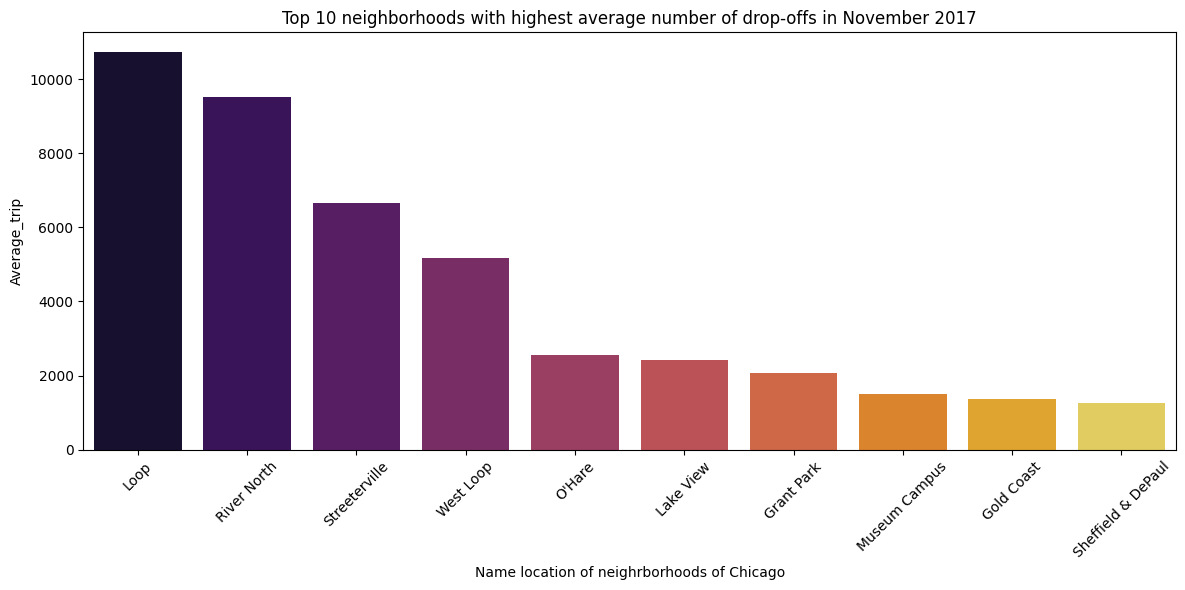

In [30]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top10_dropoff_location, x='dropoff_location_name', y='average_trips', palette='inferno')
plt.xticks(rotation=45)
plt.title('Top 10 neighborhoods with highest average number of drop-offs in November 2017')
plt.xlabel('Name location of neighrborhoods of Chicago')
plt.ylabel('Average_trip')
plt.tight_layout()
plt.show()

In [31]:
# Sumar el total de 'trips_amount'
total_trips = df_trips['trips_amount'].sum()

# Calcular el porcentaje de cada company_name
df_trips['percentage'] = (df_trips['trips_amount'] / total_trips) * 100
df_trips['percentage'] = df_trips['percentage'].round(2)

# Ordenar y mostrar los 10 principales barrios

top10_companies_name = df_trips.sort_values(by='trips_amount', ascending=False)
top10_companies_name = top10_companies_name.head(10)

# Mostrar el resultado
print(top10_companies_name)


                        company_name  trips_amount  percentage
0                          Flash Cab         19558       14.24
1          Taxi Affiliation Services         11422        8.32
2                  Medallion Leasing         10367        7.55
3                         Yellow Cab          9888        7.20
4    Taxi Affiliation Service Yellow          9299        6.77
5          Chicago Carriage Cab Corp          9181        6.69
6                       City Service          8448        6.15
7                           Sun Taxi          7701        5.61
8          Star North Management LLC          7455        5.43
9  Blue Ribbon Taxi Association Inc.          5953        4.34


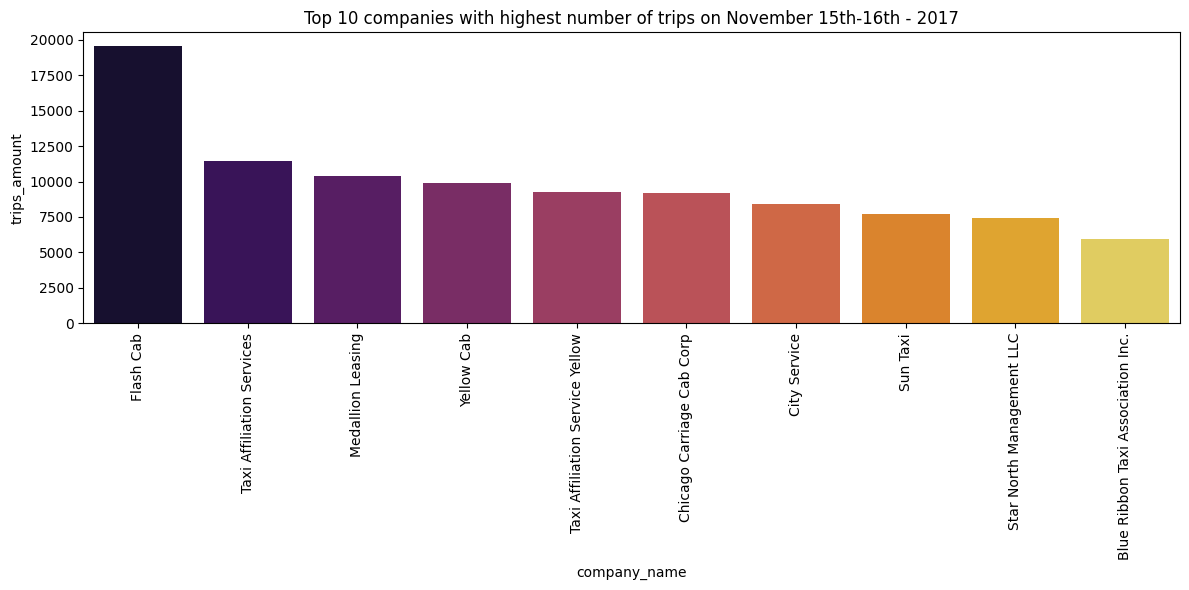

In [32]:
# Gráfico de Empresas de Taxis y Número de Viajes
plt.figure(figsize=(12, 6))
sns.barplot(data=top10_companies_name, x='company_name', y='trips_amount', palette='inferno')
plt.xticks(rotation=90)
plt.title('Top 10 companies with highest number of trips on November 15th-16th - 2017')
plt.xlabel('company_name')
plt.ylabel('trips_amount')
plt.tight_layout()
plt.show()

**Conclusión:**

La empresa Flash Cab tuvo la mayor cantidad de viajes durante el 15 y 16 de noviembre de 2017, con 19558 viajes (representa el 14.24% de los viajes totales). La segunda empresa fue Taxi Affiliation Services, con 11422 viajes (representa el 8.32% de los viajes totales). Las empresas que estan por debajo de Flash Cab, tienen una participación mucho menor. Esto indica que Flash Cab tiene una cuota de mercado considerablemente mayor que el resto de las empresas, siendo el líder del grupo.

En promedio, 10727.46 viajes en taxi terminaron en Loop, un vecindario de Chicago bastante transitado, con una gran variedad de restaurantes, tiendas, atractivos y parques. Le siguen los vecindarios River North, Streeterville y West Loop, todos ellos con un promedio mayor de 5,000 viajes terminados. Para el resto de los vecindarios, el número de descensos disminuye gradualmente. El elevado número de viajes que finalizan en ciertos vecindarios podría estar fuertemente vinculado a la densidad poblacional, la actividad comercial y la presencia de lugares de interés en esas áreas.


### PRUEBA DE HIPOTESIS

Se plantea la hipótesis nula y alternativa

La hipótesis nula (H₀) :La duración promedio de los viajes entre los sábados lluviosos y no lluviosos son iguales (no son significativamente diferentes)a pesar de las condiciones climáticas.

La hipótesis alternativa (H₁): La duración promedio de los viajes difieren significativamente dependiendo de la condición climática.

Como límite general aceptado, 95% de confianza es suficiente , por lo tanto alpha=0.05

In [34]:
# Comprobar si en la tabla solo existen los días sábado o hay más días (sábado = 5)
df_to_airport['day_of_week']=df_to_airport['start_ts'].dt.dayofweek
print(df_to_airport[df_to_airport['day_of_week']==5],'\n')
print(df_to_airport['day_of_week'].value_counts())

                start_ts weather_conditions  duration_seconds  day_of_week
0    2017-11-25 16:00:00               Good            2410.0            5
1    2017-11-25 14:00:00               Good            1920.0            5
2    2017-11-25 12:00:00               Good            1543.0            5
3    2017-11-04 10:00:00               Good            2512.0            5
4    2017-11-11 07:00:00               Good            1440.0            5
...                  ...                ...               ...          ...
1062 2017-11-11 06:00:00               Good            1500.0            5
1064 2017-11-11 10:00:00               Good            1318.0            5
1065 2017-11-11 13:00:00               Good            2100.0            5
1066 2017-11-11 08:00:00               Good            1380.0            5
1067 2017-11-04 16:00:00                Bad            2834.0            5

[1062 rows x 4 columns] 

5    1062
Name: day_of_week, dtype: int64


Comentario:<br>se comprueba que las 1062 filas pertenecen a fechas del día sabado.

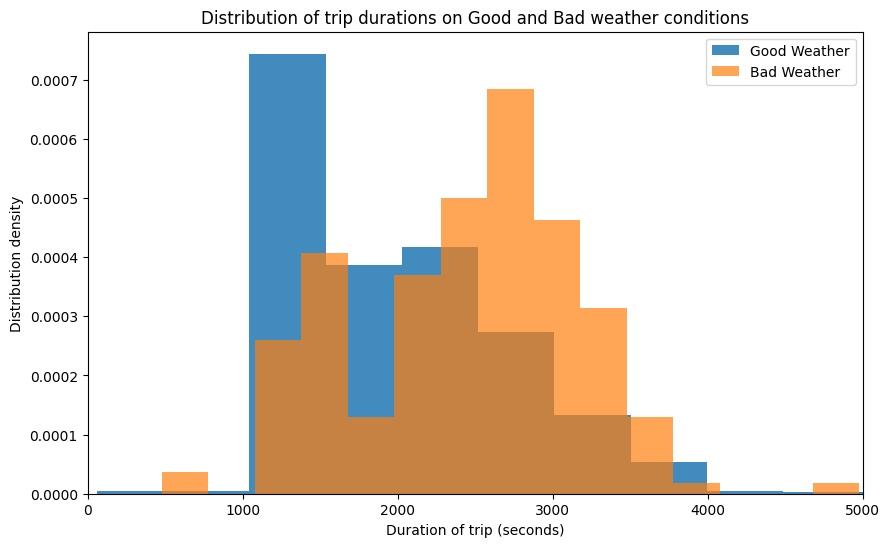

In [35]:
# Filtrar las filas con condiciones climáticas "good"
df_good_weather = df_to_airport.query('`weather_conditions` == "Good"').copy()

# Filtrar las filas con condiciones climáticas "bad"
df_bad_weather = df_to_airport.query('`weather_conditions` == "Bad"').copy()

# Crear el histograma de la columna 'duration_seconds' y mostrar el porcentaje
plt.figure(figsize=(10, 6))  # Tamaño de la figura


# Distribución para cada condición climática
df_good_weather['duration_seconds'].plot(kind='hist',bins = 15, alpha=0.85, label='Good Weather', density=True)
df_bad_weather['duration_seconds'].plot(kind='hist',bins = 15, alpha=0.7, label='Bad Weather', density=True)

# Convertir los valores de densidad a porcentaje multiplicando por 100
plt.gca().set_ylim(0, plt.gca().get_ylim()[1])  # Asegurar que el rango Y se mantenga proporcional
plt.ylabel('Distribution density')

plt.xlim(0, 5000) # Hay valores extremos , no es necesario mostrarlos

# Titulo y etiquetas
plt.legend()
plt.title('Distribution of trip durations on Good and Bad weather conditions')
plt.xlabel('Duration of trip (seconds)')

# Mostrar el gráfico
plt.show()

Comentario:<br>El histograma del tiempo de viaje en mala condicion climática refleja que hay más viajes que duren entre 1400-1700 segundos y 2600-2900 segundos. Se reflejan dos picos.<br>El histograma del tiempo de viajes en buena condicion climática refleja que hay más viaje que duren entre 1000 -1500 segundos.<br>Se observa que el tiempo de viaje durante sábados lluviosos es mayor al de sábados con buen clima.

In [36]:
print("Good weather\n", df_good_weather.describe(),"\n")
print("Bad weather\n",df_bad_weather.describe())

Good weather
        duration_seconds  day_of_week
count        882.000000        882.0
mean        2013.278912          5.0
std          743.565217          0.0
min           60.000000          5.0
25%         1397.250000          5.0
50%         1800.000000          5.0
75%         2460.000000          5.0
max         7440.000000          5.0 

Bad weather
        duration_seconds  day_of_week
count        180.000000        180.0
mean        2427.205556          5.0
std          721.314138          0.0
min          480.000000          5.0
25%         1962.000000          5.0
50%         2540.000000          5.0
75%         2928.000000          5.0
max         4980.000000          5.0


Comentario:<br>Se observa que en buen clima hay un total de 882 registros, mientras que en mal clima solo hay 180 registros. Sin embargo, los viajes en buen clima tienen una duración promedio de 2013.28 segundos. En cambio, los viajes en mal clima tienen una duración promedio mayor de 2427.21 segundos.

In [37]:
# Paso 1: Realizar la prueba de Levene para evaluar si las varianzas son iguales
# Levene asume que no hay diferencias significativas entre las varianzas si el valor p es mayor que el nivel de significancia
stat, p_value = stats.levene(df_bad_weather['duration_seconds'], df_good_weather['duration_seconds'])

# Mostrar los resultados
print(f'Estadístico de Levene: {stat}')
print(f'Valor p: {p_value}')

# Paso 5: Interpretar el valor p
alpha = 0.05  # Nivel de significancia

if p_value < alpha:
    print("Las varianzas no son iguales. Se debe usar la prueba t de Welch.")
else:
    print("Las varianzas son iguales. Se puede usar la prueba t estándar.")

Estadístico de Levene: 0.18319196347283054
Valor p: 0.6687312920630069
Las varianzas son iguales. Se puede usar la prueba t estándar.


In [38]:
# Realizar la prueba t para muestras independientes (asumiendo varianzas iguales)
t_stat, p_value_t = stats.ttest_ind(df_bad_weather['duration_seconds'], df_good_weather['duration_seconds'], equal_var=True)

# Imprimir resultados
print(f"Estadístico t: {t_stat}")
print(f"Valor p de la prueba t: {p_value_t}")

# Interpretación del resultado de la prueba t
if p_value_t < alpha:
    print("Rechazamos la hipótesis nula: hay una diferencia significativa en la duración promedio de los viajes los sábados lluviosos.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente para afirmar que la duración promedio cambia los sábados lluviosos.")

Estadístico t: 6.8404589322166425
Valor p de la prueba t: 1.3318772977743245e-11
Rechazamos la hipótesis nula: hay una diferencia significativa en la duración promedio de los viajes los sábados lluviosos.


**Conclusion:**

Con el análisis estadístico, se observa que el tiempo promedio de viaje en sábados lluviosos es significativamente diferente al tiempo promedio de viaje en buenas condiciones climáticas.<br>Tiempo promedio de viaje en buenas condiciones (2013.28±743.57) es significativamente menor al tiempo promedio de viaje en sábados lluviosos (2427.21±721.31).<br>Existen varias razones posibles por las cuales los viajes en condiciones climáticas malas (como lluvias) pueden tener una duración promedio mayor que los viajes en condiciones climáticas buenas. Algunas de las razones más comunes incluyen factores relacionados con la seguridad, el tráfico, las condiciones de manejo y el comportamiento de los conductores y pasajeros.